In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# feature extraction

In [31]:
import numpy as np
import librosa

def extract_handcrafted_features(file_path):
    
    y, sr = librosa.load(file_path, sr=16000)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)
    
    features = np.hstack([
        np.mean(mfcc, axis=1),
        np.mean(chroma, axis=1),
        np.mean(spectral_contrast, axis=1),
        np.mean(zcr, axis=1),
        np.mean(rms, axis=1)
    ])
    
    return features

In [32]:
import pandas as pd
metadata_path = '/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt'

metadata = pd.read_csv(metadata_path, sep=' ', header=None, 
                       names=['speaker', 'file_id', 'system', 'null', 'label'])

base_dir ='/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_train/flac/'
metadata['full_path'] = base_dir + metadata['file_id'] + '.flac'

print("Metadata defined successfully!")

Metadata defined successfully!


In [33]:
sample_features = extract_handcrafted_features(
    metadata['full_path'].iloc[0]
)

print(sample_features.shape)

(41,)


# creating datasets 

In [34]:
sample_metadata = metadata 

In [35]:
X = []
y = []

for _, row in sample_metadata.iterrows():
    
    try:
        features = extract_handcrafted_features(
            row['full_path']
        )
        
        X.append(features)
        y.append(row['label'])
        
    except:
        pass
        

In [36]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(25380, 41)
(25380,)


# encoding to train/test

In [37]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# training random forest usinf smote

In [39]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE:")
print(pd.Series(y_train).value_counts())

After SMOTE:
1    18240
0    18240
Name: count, dtype: int64


In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=300,
                       n_jobs=-1, random_state=42)

# prediction

In [41]:
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9950748620961387


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       516
           1       1.00      1.00      1.00      4560

    accuracy                           1.00      5076
   macro avg       0.99      0.98      0.99      5076
weighted avg       1.00      1.00      1.00      5076



# confusion matrix 

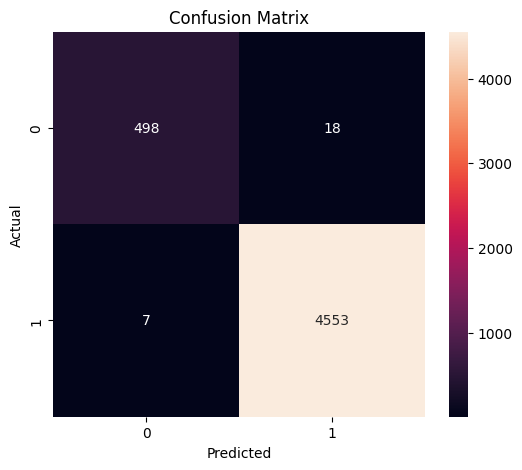

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC-AOC SCORE 

In [45]:
from sklearn.metrics import roc_auc_score

probabilities = model.predict_proba(X_test)

auc = roc_auc_score(
    y_test,
    probabilities[:,1]
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9993884298925608
